### 학습목표
- 음성데이터 구성에 대해 이해 할 수 있다
- transformer기반의 waver2vec 모델을 파인튜닝 할 수 있다

### 음성 특징 추출 기술 발전 흐름

| 시대/세대               | 주요 입력 특징                                       | 대표 활용 기술                                                | 장점                                                            | 한계                                                  |
| ------------------- | ---------------------------------------------- | ------------------------------------------------------- | ------------------------------------------------------------- | --------------------------------------------------- |
| **1980s\~2000s 초반** | **MFCC** (Mel-Frequency Cepstral Coefficients) | GMM-HMM 기반 ASR, 전통 화자 인식(i-vector)                      | - 사람 귀 모델링 반영<br>- 저차원(13\~39D) → 계산 가벼움                      | - 고주파·잡음에 취약<br>- 화자·채널 변화에 민감<br>- 프레임 간 연관성 약     |
| **2010s**           | **Mel-Spectrogram / Log-Mel**                  | DNN, CNN, RNN 기반 음향모델<br>(DeepSpeech, CNN-HMM hybrid 등) | - 더 풍부한 주파수-시간 정보 보존<br>- 이미지처럼 CNN 적용 가능                     | - 여전히 handcrafted feature (STFT, Mel filterbank 필요) |
| **2016\~현재**        | **Waveform 직접 입력 (raw audio)**                 | End-to-End 모델 (WaveNet, wav2vec, HuBERT, Whisper 등)     | - 특징 추출 자동 학습<br>- 큰 데이터로 “최적 특징”을 스스로 학습<br>- 잡음·화자 변화에 더 강함 | - 연산량↑, 대규모 데이터·모델 필요<br>- 작은 데이터셋 학습은 어려움          


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/AI/인사교_자연어처리

/content/drive/MyDrive/AI/인사교_자연어처리


음성데이터 태스크(task) 종류

| 분야                                               | 주요 목표              | 입력 특징                                       | 대표 기술/알고리즘                                                      | 활용 사례                   |
| ------------------------------------------------ | ------------------ | ------------------------------------------- | --------------------------------------------------------------- | ----------------------- |
| **음성 전처리 (Speech Signal Processing)**            | 신호 정제 & 특징 추출      | Waveform, STFT                              | VAD(음성구간검출), 잡음제거, Mel-Spectrogram, MFCC                        | 녹음 전처리, ASR 입력 준비       |
| **자동 음성 인식 (ASR, Automatic Speech Recognition)** | “사람이 말한 걸 문자로 바꾸기” | MFCC, Mel-Spec, (최근 Waveform)               | HMM-GMM, DNN-HMM, CTC, RNN-Transducer, Transformer, Whisper     | 자막 생성, AI 비서, 회의록       |
| **화자 인식 (Speaker Recognition)**                  | “누가 말했는가?”         | MFCC, i-vector, x-vector, speaker embedding | GMM-UBM, i-vector+PLDA, x-vector+DNN                            | 보안 인증, 출입 통제            |
| **화자 분할 (Speaker Diarization)**                  | “언제 누가 말했는가?”      | MFCC, Embedding                             | 군집화(K-means, Spectral), x-vector diarization, EEND              | 회의 기록, 방송 자막            |
| **화자 분리 (Speech Separation)**                    | “동시에 말한 목소리 분리”    | Waveform, STFT (복소수)                        | ICA, NMF, PIT, Conv-TasNet, SepFormer                           | 회의 다화자 분리, 보청기          |
| **음성 합성 (TTS, Text-to-Speech)**                  | “글자를 소리로 바꾸기”      | 텍스트, phoneme                                | Concatenative, HMM-TTS, Tacotron, FastSpeech, WaveNet, HiFi-GAN | 음성 안내, 내레이션, AI 성우      |
| **키워드 스팟팅 (Keyword Spotting)**                   | “특정 단어 탐지”         | MFCC, Mel-Spec                              | DTW, GMM/SVM, CNN/DS-CNN, CRNN                                  | “Hey Siri”, “OK Google” |
| **감정 인식 (Speech Emotion Recognition)**           | “말투로 감정 파악”        | MFCC, Mel-Spec, Embedding                   | SVM, CNN+LSTM, Transformer                                      | 상담 분석, 헬스케어 모니터링        |
| **음성 이해 (SLU, Spoken Language Understanding)**   | “말의 의미와 의도 해석”     | 텍스트+Prosody                                 | Intent classification, Joint ASR+NLU                            | AI 챗봇, 대화형 AI           | ```

### 아날로그와 디지털

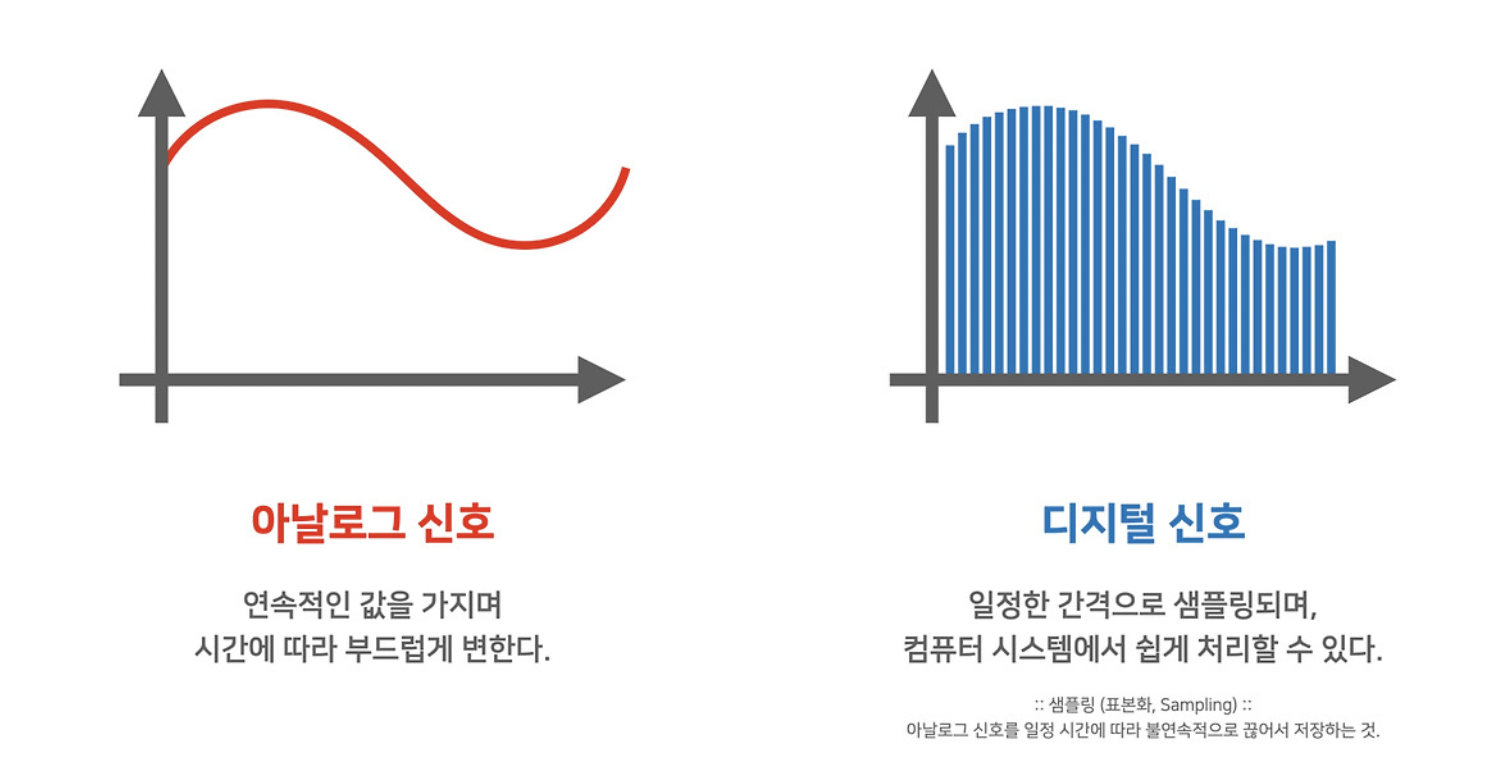

### 샘플링레이트(sampling rate)
- 샘플링: 아날로그 신호를 디지털로 저장하는 과정(표본화)
- 레이트 : 시간당 샘플링 횟수(44.1kHz->1초에 44100번 추출)
- 인간의 가청주파수 : 20Hz ~ 20kHz
- 일반적인 사람의 목소리 주파수 : 0Hz ~ 8kHz
- 나이퀴스트-섀넌(Nyquist-Shannon sampling theorem) 샘플링 이론: 특정신호에서 가장 높은 진동수의 2배에 해당하는 간격으로 샘플링하면 원래 신호로 복원이 가능하다
- 음원데이터는 44.1kHz, 음성분석도구는 16kHz
- Sampling Frequency의 의미는 'Signal Frequency'의 2배 미만으로 낮춘거고 점들을 이은 선(디지털 복원 결과)이 원래의 부드러운 파동과는 완전히 다른 엉뚱한 모양(에일리어싱)으로 변하는 걸 볼 수 있어